# 13.3 · Canny step by step

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain canny step by step using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[05 · Image Processing](../../05-image-processing/README.md), [09 · Feature Detection](../../09-feature-detection/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Edges are rapid changes in image intensity. They often correspond to boundaries, but also arise from texture, shadows and noise. A derivative measures change; a good edge pipeline controls noise and decides which changes should form connected boundaries.

## 2. Intuition

Canny smooths the image, estimates gradients, thins responses through non-maximum suppression, applies high and low thresholds, and keeps weak edges connected to strong ones through hysteresis. The reference uses four orientation bins and relative thresholds; OpenCV has different implementation details and absolute thresholds, so exact edge maps are not expected.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 13
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
G=\sqrt{G_x^2+G_y^2},\qquad\theta=\operatorname{atan2}(G_y,G_x)
$$

Gx and Gy are horizontal and vertical derivatives, G their magnitude and θ edge-normal orientation. Derivatives (3,4) have magnitude 5 and orientation about 53.13 degrees.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
gx, gy = 3.0, 4.0
magnitude = np.hypot(gx, gy)
orientation = np.degrees(np.arctan2(gy, gx))
assert magnitude == 5
print(magnitude, orientation)

5.0 53.13010235415598


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

Follow the NumPy implementation in order: Gaussian blur → Sobel → magnitude/orientation → directional suppression → two thresholds → queue-based hysteresis. Compare intermediate arrays, not only the final binary output.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def edges(lesson, seed, amount):
    image = n.gray(picture(seed))
    gx, gy, magnitude = n.sobel(image)
    ref = n.canny_reference(image, low=0.08 * amount, high=0.2 * amount)
    lib = cv2.Canny(image.astype(np.uint8), 50 * amount, 120 * amount)
    if lesson == 1:
        lib = cv2.Laplacian(image, cv2.CV_64F)
    if lesson == 2:
        lib = cv2.Scharr(image, cv2.CV_64F, 1, 0)
    return Result(
        "13 · Gradients, thinning and hysteresis",
        {
            "Input": image,
            "Horizontal derivative": gx,
            "Vertical derivative": gy,
            "Magnitude": magnitude,
            "Reference Canny": ref,
            "OpenCV comparison": lib,
        },
        metrics={"reference_edge_pixels": int(ref.sum())},
        notes="Simplified Canny uses four quantized directions and relative thresholds; it is not bit-identical to OpenCV Canny.",
    )

{
  "reference_edge_pixels": 541
}
Simplified Canny uses four quantized directions and relative thresholds; it is not bit-identical to OpenCV Canny.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import canny_reference

display(Code(inspect.getsource(canny_reference), language="python"))

def canny_reference(image, low=0.1, high=0.25):
    """Simplified Canny: smooth, Sobel, four-direction NMS, hysteresis."""
    if not 0 < low <= high <= 1:
        raise ValueError("Require 0 < low <= high <= 1 for relative thresholds.")
    smoothed = correlate(gray(image), gaussian_kernel())
    gx, gy, magnitude = sobel(smoothed)
    orientation = (np.rad2deg(np.arctan2(gy, gx)) + 180) % 180
    thinned = np.zeros_like(magnitude)
    offsets = [(0, 1), (1, 1), (1, 0), (1, -1)]
    for y in range(1, magnitude.shape[0] - 1):
        for x in range(1, magnitude.shape[1] - 1):
            direction = int((orientation[y, x] + 22.5) // 45) % 4
            dy, dx = offsets[direction]
            value = magnitude[y, x]
            if value >= magnitude[y + dy, x + dx] and value >= magnitude[y - dy, x - dx]:
                thinned[y, x] = value
    if thinned.max() == 0:
        return np.zeros_like(thinned, bool)
    strong = thinned >= high * thinned.max()
    weak = thinned >= low * thinned.max()
    queue = deque(zip(*np.nonzero(strong), strict=True))
    while queue:
        y, x = queue.popleft()
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                yy, xx = y + dy, x + dx
                if 0 <= yy < strong.shape[0] and 0 <= xx < strong.shape[1]:
                    if weak[yy, xx] and not strong[yy, xx]:
                        strong[yy, xx] = True
                        queue.append((yy, xx))
    return strong

## 8. Experiment

Increase noise and independently change blur scale and hysteresis thresholds. Observe missing boundaries versus false texture edges.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "reference_edge_pixels": 541
  },
  "second_seed": {
    "reference_edge_pixels": 541
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

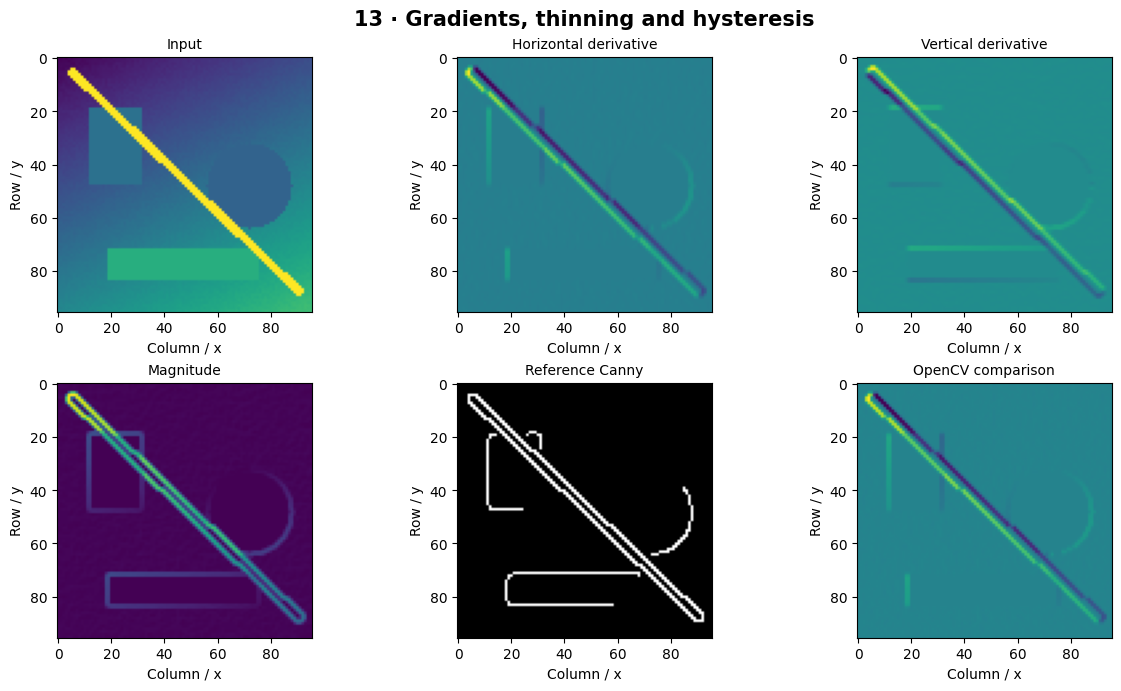

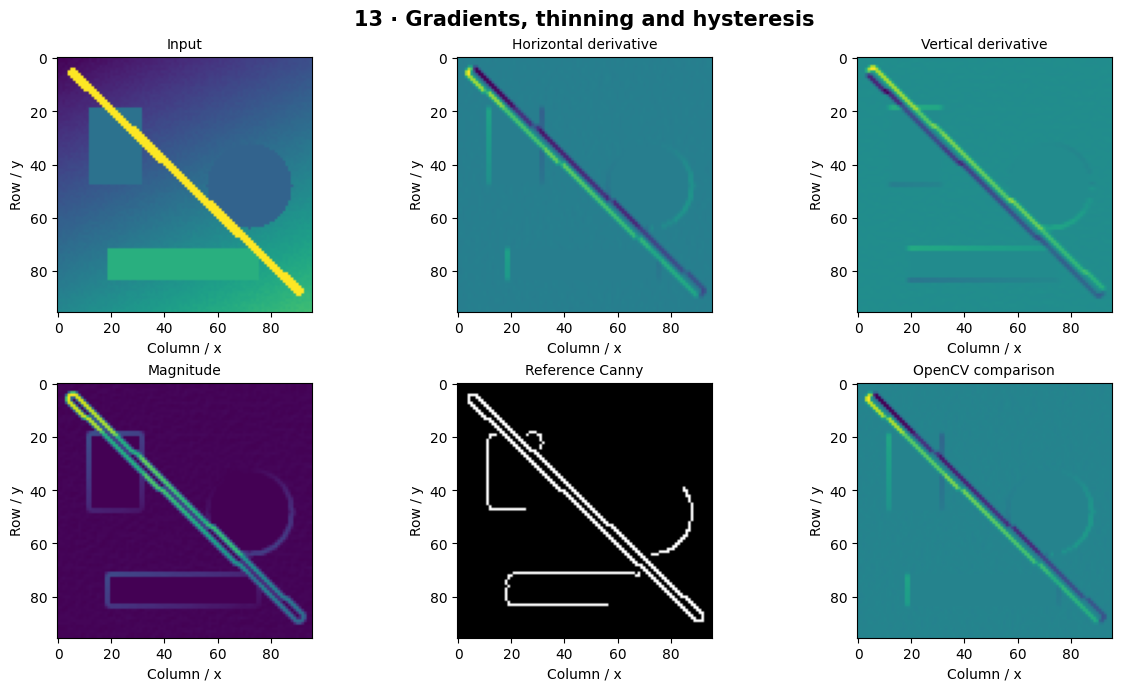

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Document Boundary Detector**. Construct a simplified Canny pipeline and evaluate noise effects. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Edges are not closed object masks. Applying contours to a broken Canny map can produce fragmented shapes.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Increase noise and independently change blur scale and hysteresis thresholds. Observe missing boundaries versus false texture edges.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Detect a document boundary from gradients, reject implausible quadrilaterals, and rectify the highest-quality candidate.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Canny smooths the image, estimates gradients, thins responses through non-maximum suppression, applies high and low thresholds, and keeps weak edges connected to strong ones through hysteresis. The reference uses four orientation bins and relative thresholds; OpenCV has different implementation details and absolute thresholds, so exact edge maps are not expected.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[14 · Classical Segmentation](../../14-segmentation-classical/README.md)

[Primary reference](https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)